In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

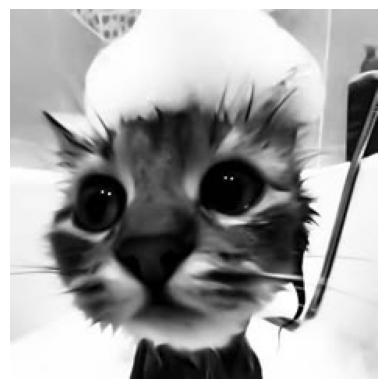

In [2]:
image = cv2.imread('mykitty.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [3]:
# Построение гистограммы через OpenCV
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

hist = hist.flatten()


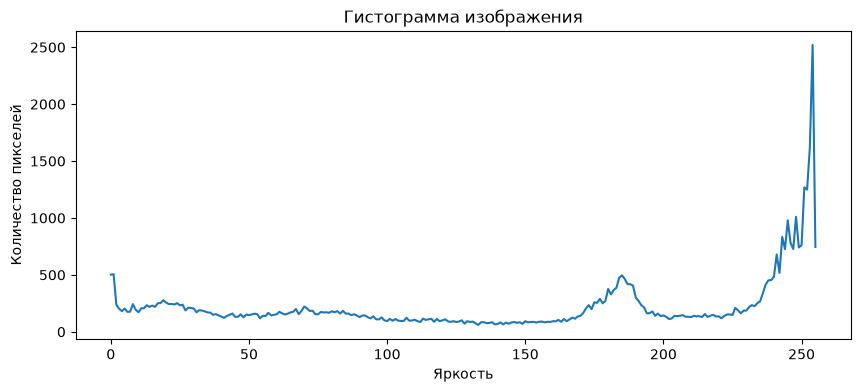

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(hist)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма изображения')
plt.show()


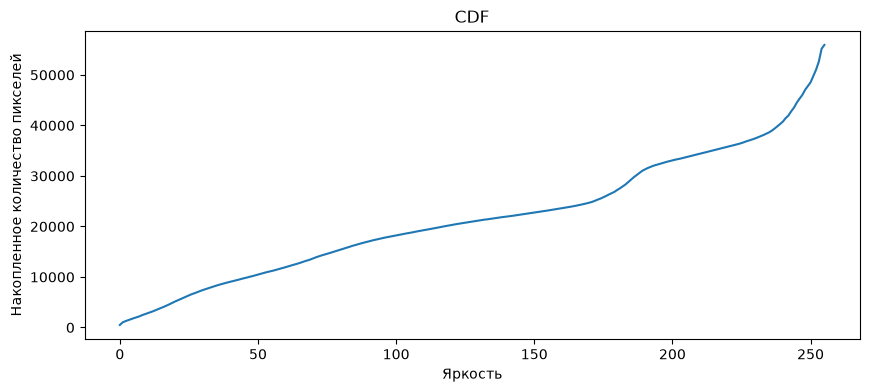

In [5]:
# Накопленная гистограмма
cdf = hist.cumsum()

plt.figure(figsize=(10, 4))
plt.plot(cdf)
plt.xlabel('Яркость')
plt.ylabel('Накопленное количество пикселей')
plt.title('CDF')
plt.show()


In [6]:
# Эквализация гистограммы через OpenCV
equalized_image = cv2.equalizeHist(image)


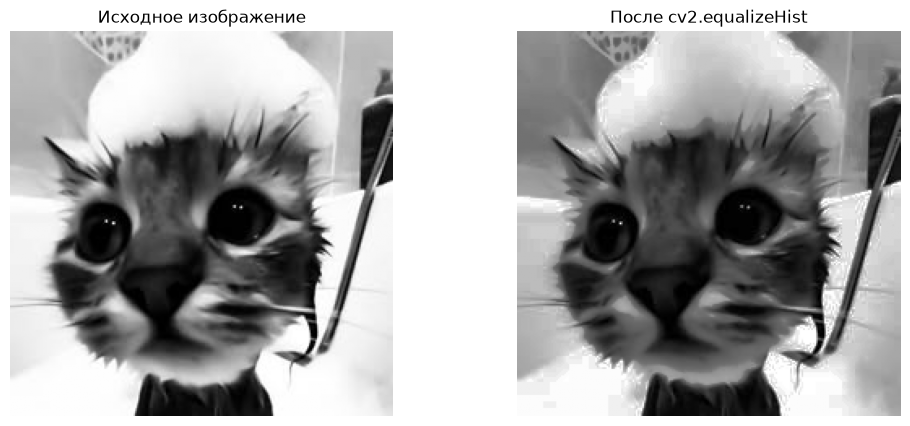

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title('После cv2.equalizeHist')
plt.axis('off')

plt.show()


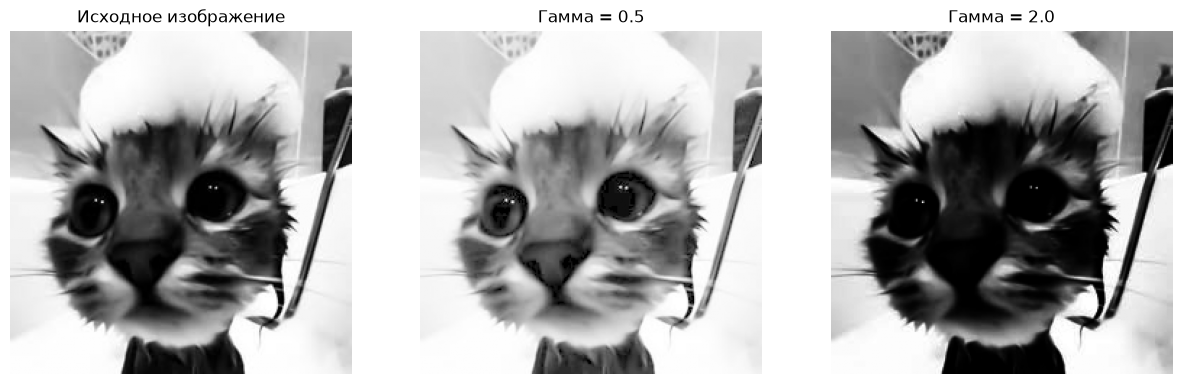

In [8]:
gamma1 = 0.5
gamma2 = 2.0

gamma_image1 = np.array(
    255 * (image / 255) ** gamma1,
    dtype=np.uint8
)

gamma_image2 = np.array(
    255 * (image / 255) ** gamma2,
    dtype=np.uint8
)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gamma_image1, cmap='gray')
plt.title('Гамма = 0.5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gamma_image2, cmap='gray')
plt.title('Гамма = 2.0')
plt.axis('off')

plt.show()

In [9]:
from skimage.metrics import structural_similarity, mean_squared_error

mse_gamma1 = mean_squared_error(image, gamma_image1)
ssim_gamma1 = structural_similarity(image, gamma_image1)

mse_gamma2 = mean_squared_error(image, gamma_image2)
ssim_gamma2 = structural_similarity(image, gamma_image2)

print("Gamma = 0.5")
print("MSE:", mse_gamma1)
print("SSIM:", ssim_gamma1)

print("\nGamma = 2.0")
print("MSE:", mse_gamma2)
print("SSIM:", ssim_gamma2)

Gamma = 0.5
MSE: 1454.5662947865264
SSIM: 0.8511338322602565

Gamma = 2.0
MSE: 1446.3925480941143
SSIM: 0.744004492082737


In [10]:
mean = image.mean()
std = image.std()

print("Среднее значение:", mean)
print("Стандартное отклонение:", std)

Среднее значение: 156.23451691339483
Стандартное отклонение: 87.35159632766904


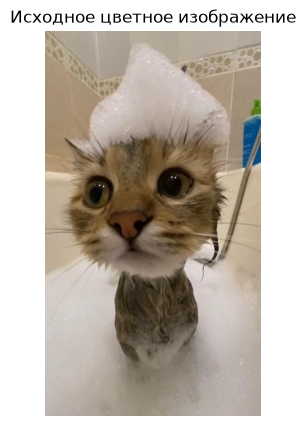

In [11]:
color_image = cv2.imread('mykittycolor.jpg')

color_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(color_image)
plt.title('Исходное цветное изображение')
plt.axis('off')
plt.show()

In [12]:
eq_gray = equalized_image

print('Среднее исходного изображения:', np.mean(image))
print('Стандартное отклонение исходного:', np.std(image))

print('Среднее eq_gray:', np.mean(eq_gray))
print('Стандартное отклонение eq_gray:', np.std(eq_gray))

Среднее исходного изображения: 156.23451691339483
Стандартное отклонение исходного: 87.35159632766904
Среднее eq_gray: 127.49358149181148
Стандартное отклонение eq_gray: 75.21983380717413


In [13]:
target_mean = np.mean(eq_gray)
target_std = np.std(eq_gray)

print("Целевое среднее:", target_mean)
print("Целевое стандартное отклонение:", target_std)

Целевое среднее: 127.49358149181148
Целевое стандартное отклонение: 75.21983380717413


In [19]:
lab = cv2.cvtColor(color_image, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

l_equalized = cv2.equalizeHist(l)

lab_corrected = cv2.merge((l_equalized, a, b))

corrected_color = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

print("Статистическая цветокоррекция выполнена")



Статистическая цветокоррекция выполнена


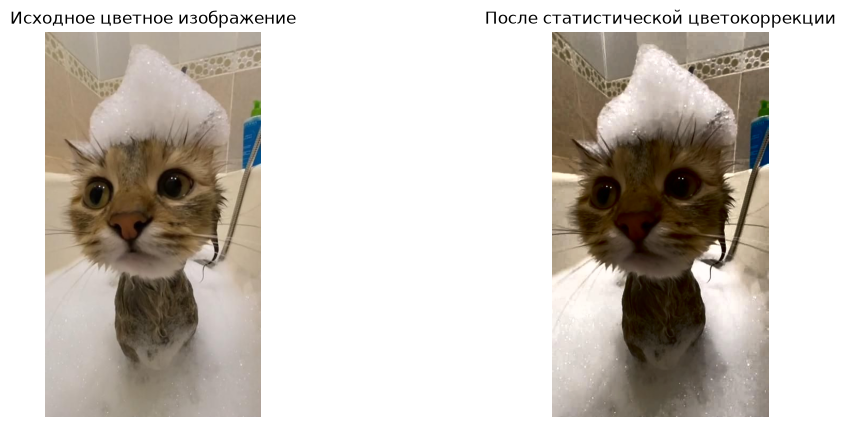

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(color_image)
plt.title('Исходное цветное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(corrected_color)
plt.title('После статистической цветокоррекции')
plt.axis('off')

plt.show()

In [ ]:
thresholds = [50, 100, 150, 200]

plt.figure(figsize=(15, 10))

for i, threshold in enumerate(thresholds):
    
    _, binary = cv2.threshold(
        image,
        threshold,
        255,
        cv2.THRESH_BINARY
    )
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Порог = {threshold}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
threshold = 120

_, binary = cv2.threshold(
    image,
    threshold,
    255,
    cv2.THRESH_BINARY
)

_, binary_inv = cv2.threshold(
    image,
    threshold,
    255,
    cv2.THRESH_BINARY_INV
)

_, otsu = cv2.threshold(
    image,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap='gray')
plt.title('Обычная бинаризация')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_inv, cmap='gray')
plt.title('Инвертированная бинаризация')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(otsu, cmap='gray')
plt.title('Бинаризация Otsu')
plt.axis('off')

plt.show()